## Note: legacy notebook (v5 monthly target)

This notebook documents the v5 model training pipeline, which used a 21-day
(monthly) forward-return target. The dashboard runs on the v6 quarterly
pipeline. See `model_v6_quarterly.ipynb` for the current model training
notebook.

The v5 joblib artefacts (`rf_return_v5.joblib`, `rf_volatility_v5.joblib`)
are no longer kept under `models/`. The cells below are preserved as a
development record of how the modelling pipeline evolved.


In [22]:
import sys
from pathlib import Path
sys.path.insert(0, str(Path.cwd().parent))

import pandas as pd
import numpy as np
from sklearn.ensemble import RandomForestRegressor
from sklearn.metrics import mean_squared_error, r2_score, mean_absolute_error
from scipy.stats import spearmanr
from sklearn.model_selection import TimeSeriesSplit, GridSearchCV
import joblib
import matplotlib.pyplot as plt
import seaborn as sns


In [2]:
# Regenerate features with new additions
from src.features.engineer import build_features
from src.data.ingest import build_universe, download_prices, clean_prices



cache = Path("../data/raw/prices.parquet")
tickers = build_universe()
raw_df = download_prices(tickers, cache)
clean_df, _ = clean_prices(raw_df)

features_df = build_features(clean_df)
features_clean = features_df.dropna()
features_clean.to_parquet("../data/processed/features.parquet")
print(features_clean.shape)


Loading cached data from ../data/raw/prices.parquet
Dropping 7 tickers: ['AAF.L', 'CCEP.L', 'EDV.L', 'HLN.L', 'MNG.L', 'MTLN.L', 'PSH.L']


/var/folders/c1/b4w8jwwx5gscsnykncp6_dym0000gn/T/ipykernel_58497/2097159685.py:10: UserWarning: clean_prices: 2 ticker(s) have leading NaN after ffill (post-listing tickers): CTEC.L(467), AUTO.L(54). These cells are NOT bfilled to avoid look-ahead bias; downstream feature engineering will propagate NaN through rolling windows and drop the affected rows.
  clean_df, _ = clean_prices(raw_df)


(246022, 9)


In [3]:
# Load features
features_clean = pd.read_parquet("../data/processed/features.parquet")

# Define feature columns and targets
FEATURE_COLS = [
    "momentum", "volatility_21d", "drawdown_52w",
    "relative_strength", "volume_ratio_20", "beta_252", "vix"
]


# Three-way split
# Tuning window: used for CV-based hyperparameter search
# Held-out: touched exactly once for final evaluation

tuning = features_clean[
    features_clean.index.get_level_values("date") < "2024-01-01"
]

held_out = features_clean[
    features_clean.index.get_level_values("date") >= "2024-01-01"
]

print(f"Tuning window: {tuning.shape}")
print(f"Held-out:      {held_out.shape}")


X_tune     = tuning[FEATURE_COLS]
y_tune_ret = tuning["forward_return"]
y_tune_vol = tuning["forward_volatility"]

X_held     = held_out[FEATURE_COLS]
y_held_ret = held_out["forward_return"]
y_held_vol = held_out["forward_volatility"]


Tuning window: (191245, 9)
Held-out:      (54777, 9)


The held-out set (2024-01-01 onwards) is reserved for final evaluation only and is not used for model selection, feature engineering decisions, or any intermediate analysis. It is evaluated exactly once.


In [4]:
class PurgedTimeSeriesSplit:
    """
    TimeSeriesSplit with purging and embargo to prevent target-window leakage
    in panel data. Operates on date level, purging all tickers simultaneously.

    For each validation fold [val_start, val_end]:
      - Any training row whose 21-day target window overlaps
        [val_start - embargo, val_end] is removed from training.

    """

    def __init__(self, n_splits=5, horizon_td=21, embargo_td=5):
        self.n_splits   = n_splits
        self.horizon_td = horizon_td  # prediction horizon in trading days
        self.embargo_td = embargo_td  # embargo buffer in trading days

    def split(self, X, y=None, groups=None):
        dates        = X.index.get_level_values("date")
        unique_dates = np.sort(dates.unique())

        tscv = TimeSeriesSplit(n_splits=self.n_splits)

        for train_date_idx, val_date_idx in tscv.split(unique_dates):
            train_dates = unique_dates[train_date_idx]
            val_dates   = unique_dates[val_date_idx]

            val_start_pos = np.searchsorted(unique_dates, val_dates.min())

            # Purge training rows whose target window reaches into the
            # embargo zone before val_start
            purge_pos = max(0, val_start_pos - self.horizon_td - self.embargo_td)
            purge_cutoff = unique_dates[purge_pos]

            purged_train_dates = train_dates[train_dates < purge_cutoff]

            train_mask = dates.isin(set(purged_train_dates))
            val_mask   = dates.isin(set(val_dates))

            yield np.where(train_mask)[0], np.where(val_mask)[0]

    def get_n_splits(self, X=None, y=None, groups=None):
        return self.n_splits


purged_cv = PurgedTimeSeriesSplit(n_splits=5, horizon_td=21, embargo_td=5)
print("Purged CV splitter ready.")

# Sanity check: print fold sizes
for i, (tr, val) in enumerate(purged_cv.split(X_tune)):
    print(f"Fold {i+1}: train={len(tr):,}  val={len(val):,}")

Purged CV splitter ready.
Fold 1: train=29,478  val=31,779
Fold 2: train=61,231  val=31,899
Fold 3: train=93,130  val=31,899
Fold 4: train=125,029  val=31,899
Fold 5: train=156,928  val=31,899


In [5]:
# --- Return baseline: rolling historical mean (pooled across tickers) ---
# On each date, predict the mean of all forward returns observed before that date

all_dates = features_clean.index.get_level_values("date").unique().sort_values()

# Compute expanding mean of forward_return up to each date
daily_mean_return = (
    features_clean["forward_return"]
    .groupby(level="date").mean()
    .expanding().mean()
    .shift(1)  # use only past information
)

# Align to held-out set
held_out_dates = held_out.index.get_level_values("date")
baseline_ret_pred = daily_mean_return.reindex(held_out_dates).values

# --- Volatility baseline: persistence (current vol_21d as forecast) ---
baseline_vol_pred = held_out["volatility_21d"].values

# --- Baseline metrics ---
from sklearn.metrics import mean_absolute_error

r2_base_ret   = r2_score(y_held_ret, baseline_ret_pred)
rmse_base_ret = np.sqrt(mean_squared_error(y_held_ret, baseline_ret_pred))
mae_base_ret  = mean_absolute_error(y_held_ret, baseline_ret_pred)

r2_base_vol   = r2_score(y_held_vol, baseline_vol_pred)
rmse_base_vol = np.sqrt(mean_squared_error(y_held_vol, baseline_vol_pred))
mae_base_vol  = mean_absolute_error(y_held_vol, baseline_vol_pred)

print("Return baseline (historical mean):")
print(f"  R²={r2_base_ret:.4f}  RMSE={rmse_base_ret:.4f}  MAE={mae_base_ret:.4f}")
print("\nVolatility baseline (persistence):")
print(f"  R²={r2_base_vol:.4f}  RMSE={rmse_base_vol:.4f}  MAE={mae_base_vol:.4f}")


Return baseline (historical mean):
  R²=-0.0030  RMSE=0.0800  MAE=0.0591

Volatility baseline (persistence):
  R²=-0.3591  RMSE=0.1391  MAE=0.0903


In [6]:
param_grid = {
    "max_depth":        [5, 8],
    "min_samples_leaf": [50, 100, 200],
    "max_features":     [2, 3, "sqrt", 0.5]
}

rf_tuned = RandomForestRegressor(
    n_estimators=500,
    random_state=42,
    n_jobs=-1
)

# Return RF
gs_ret = GridSearchCV(rf_tuned, param_grid, cv=purged_cv,
                      scoring="r2", verbose=1)
gs_ret.fit(X_tune, y_tune_ret)
print(f"Return RF , best params: {gs_ret.best_params_}, CV R²: {gs_ret.best_score_:.4f}")


Fitting 5 folds for each of 24 candidates, totalling 120 fits


Return RF  — best params: {'max_depth': 5, 'max_features': 2, 'min_samples_leaf': 200}, CV R²: -0.0141


In [7]:
param_grid = {
    "max_depth":        [5, 8],
    "min_samples_leaf": [50, 100, 200],
    "max_features":     [2, 3, "sqrt", 0.5]
}

rf_tuned = RandomForestRegressor(
    n_estimators=500,
    random_state=42,
    n_jobs=-1
)
# volume RandomForestRegressor
gs_vol = GridSearchCV(rf_tuned, param_grid, cv=purged_cv,
                      scoring="r2", verbose=1)
gs_vol.fit(X_tune, y_tune_vol)
print(f"Volatility RF, best params: {gs_vol.best_params_}, CV R²: {gs_vol.best_score_:.4f}")


Fitting 5 folds for each of 24 candidates, totalling 120 fits
Volatility RF — best params: {'max_depth': 8, 'max_features': 2, 'min_samples_leaf': 50}, CV R²: 0.1359



=== Return RF — all grid cells, ranked by mean CV score ===
 max_depth max_features  min_samples_leaf  mean_cv  std_cv  rank     model
         5            2               200  -0.0141  0.0292     1 Return RF
         5         sqrt               200  -0.0141  0.0292     1 Return RF
         5         sqrt               100  -0.0158  0.0281     3 Return RF
         5            2               100  -0.0158  0.0281     3 Return RF
         5         sqrt                50  -0.0194  0.0303     5 Return RF
         5            2                50  -0.0194  0.0303     5 Return RF
         5          0.5               200  -0.0226  0.0320     7 Return RF
         5            3               200  -0.0226  0.0320     7 Return RF
         5          0.5               100  -0.0237  0.0310     9 Return RF
         5            3               100  -0.0237  0.0310    10 Return RF
         8            2               200  -0.0264  0.0385    11 Return RF
         8         sqrt               2

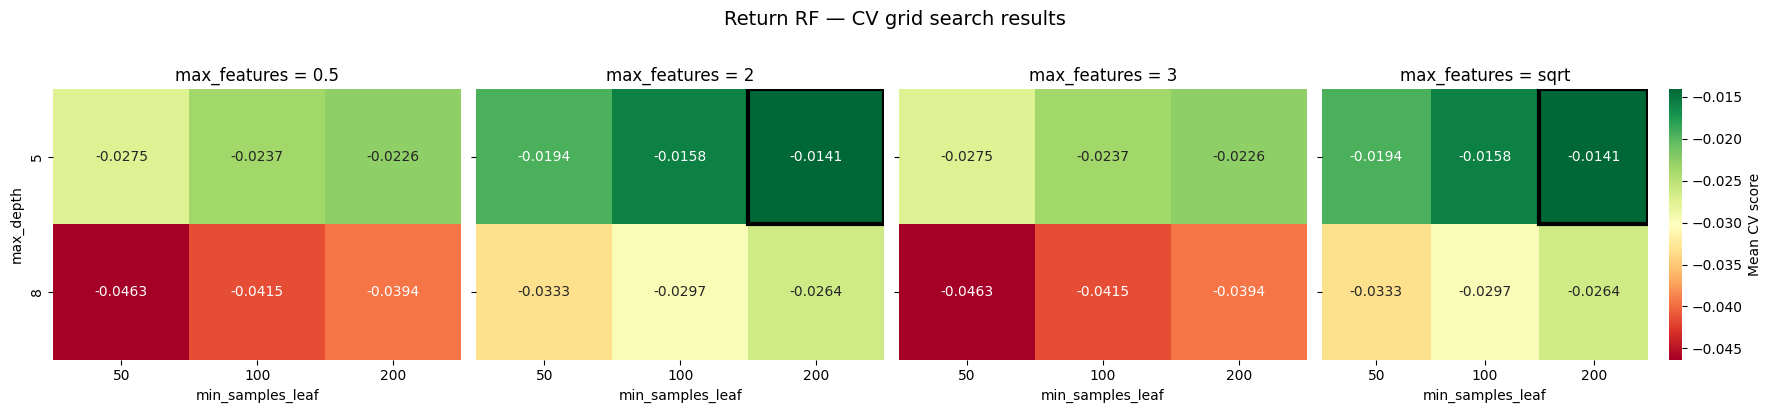

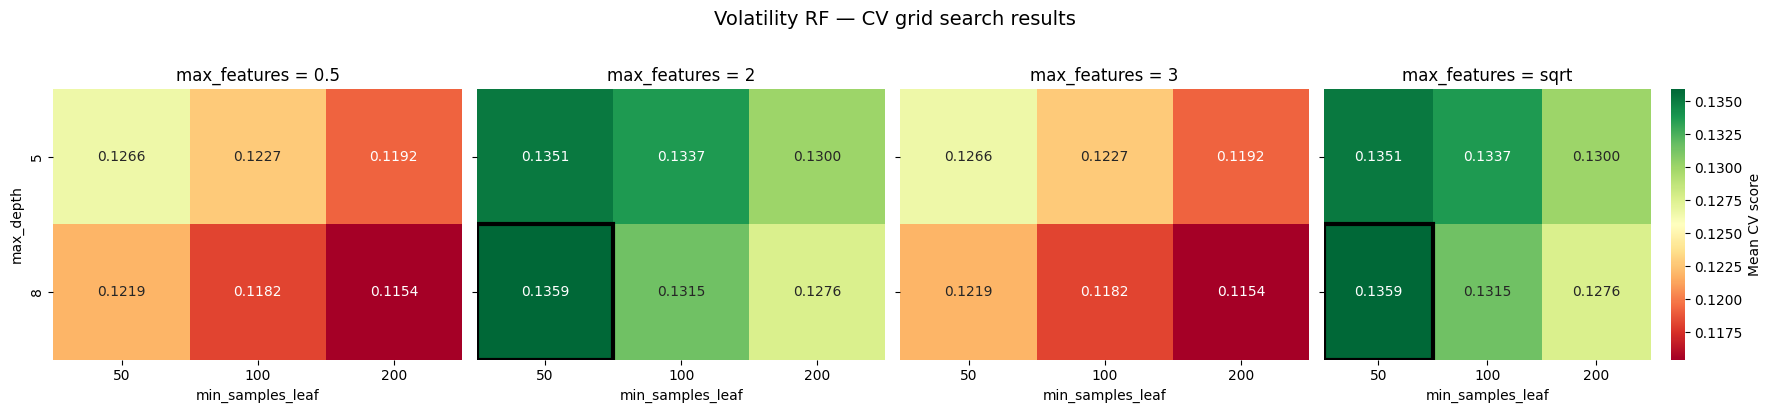

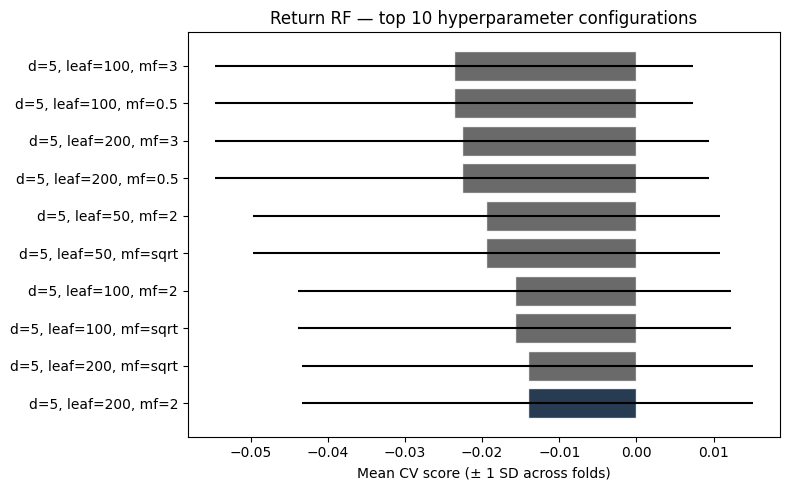

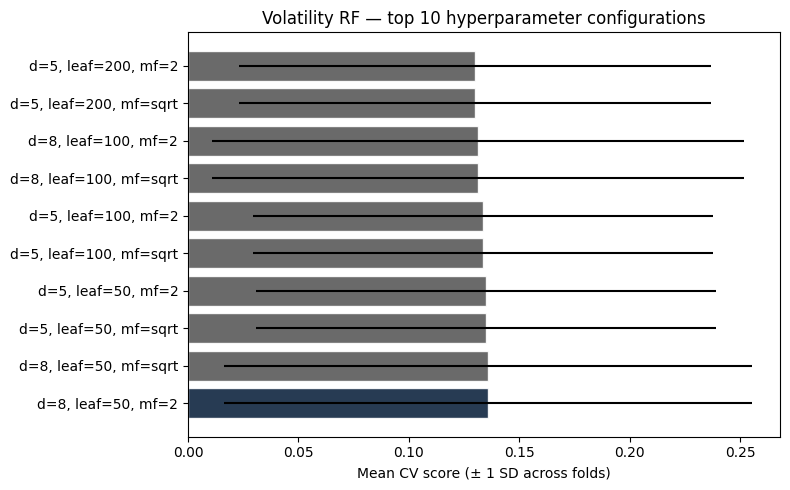


Saved grid results to data/processed/grid_results_*_v5.parquet


In [24]:
# ----- 1. Extract tidy DataFrame from each GridSearchCV ------------------
def grid_to_df(grid, model_label):
    """Pull cv_results_ into a clean DataFrame, drop bookkeeping cols."""
    cv = pd.DataFrame(grid.cv_results_)
    param_cols = [c for c in cv.columns if c.startswith("param_")]
    keep = param_cols + ["mean_test_score", "std_test_score", "rank_test_score"]
    out = cv[keep].copy()
    out.columns = [c.replace("param_", "") for c in param_cols] + [
        "mean_cv", "std_cv", "rank",
    ]
    # Cast max_features to string for clean display ('sqrt', '0.5', '2', '3')
    if "max_features" in out.columns:
        out["max_features"] = out["max_features"].astype(str)
    out["model"] = model_label
    return out.sort_values("rank").reset_index(drop=True)

df_return = grid_to_df(gs_ret, "Return RF")
df_vol    = grid_to_df(gs_vol,    "Volatility RF")

# ----- 2. Print the ranked table (useful as a methodology appendix) ------
def show_ranked(df, model_label):
    print(f"\n=== {model_label}, all grid cells, ranked by mean CV score ===")
    print(df.to_string(index=False, float_format=lambda x: f"{x:.4f}"))

show_ranked(df_return, "Return RF")
show_ranked(df_vol,    "Volatility RF")

# ----- 3. Heatmap: max_depth × min_samples_leaf, faceted by max_features --
def plot_grid_heatmap(df, model_label, primary_metric="Mean CV score"):
    mfs = sorted(df["max_features"].unique())
    fig, axes = plt.subplots(1, len(mfs), figsize=(4.5 * len(mfs), 4), sharey=True)
    if len(mfs) == 1:
        axes = [axes]
    # Shared colour scale across facets so cross-facet comparison is honest
    vmin, vmax = df["mean_cv"].min(), df["mean_cv"].max()
    for ax, mf in zip(axes, mfs):
        sub = df[df["max_features"] == mf]
        pivot = sub.pivot(index="max_depth", columns="min_samples_leaf", values="mean_cv")
        sns.heatmap(
            pivot, annot=True, fmt=".4f",
            ax=ax, cmap="RdYlGn", vmin=vmin, vmax=vmax,
            cbar=(ax is axes[-1]),
            cbar_kws={"label": primary_metric} if ax is axes[-1] else None,
        )
        ax.set_title(f"max_features = {mf}")
        ax.set_xlabel("min_samples_leaf")
        ax.set_ylabel("max_depth" if ax is axes[0] else "")
    # Mark winning cell (rank == 1) in each facet
    for ax, mf in zip(axes, mfs):
        sub = df[(df["max_features"] == mf) & (df["rank"] == df[df["max_features"] == mf]["rank"].min())]
        if not sub.empty and sub["rank"].iloc[0] == 1:
            row = sub.iloc[0]
            mds = sorted(df["max_depth"].unique())
            msls = sorted(df["min_samples_leaf"].unique())
            y = mds.index(row["max_depth"]) + 0.5
            x = msls.index(row["min_samples_leaf"]) + 0.5
            ax.add_patch(plt.Rectangle((x - 0.5, y - 0.5), 1, 1,
                                        fill=False, edgecolor="black", lw=3))
    plt.suptitle(f"{model_label}, CV grid search results", y=1.02, fontsize=14)
    plt.tight_layout()
    plt.show()

plot_grid_heatmap(df_return, "Return RF")
plot_grid_heatmap(df_vol,    "Volatility RF")

# ----- 4. (Optional) Bar plot of the top 10 configurations ---------------
def plot_top_n(df, model_label, n=10):
    top = df.head(n).copy()
    top["label"] = top.apply(
        lambda r: f"d={int(r['max_depth'])}, leaf={int(r['min_samples_leaf'])}, mf={r['max_features']}",
        axis=1,
    )
    fig, ax = plt.subplots(figsize=(8, 0.4 * n + 1))
    colors = ["#0F2540" if i == 0 else "#5A5A5A" for i in range(len(top))]
    ax.barh(top["label"][::-1], top["mean_cv"][::-1], xerr=top["std_cv"][::-1],
            color=colors[::-1], edgecolor="white", alpha=0.9)
    ax.set_xlabel("Mean CV score (± 1 SD across folds)")
    ax.set_title(f"{model_label}, top {n} hyperparameter configurations")
    ax.invert_yaxis()
    plt.tight_layout()
    plt.show()

plot_top_n(df_return, "Return RF")
plot_top_n(df_vol,    "Volatility RF")

# ----- 5. Save for the dissertation appendix -----------------------------
df_return.to_parquet("../data/processed/grid_results_return_v5.parquet", index=False)
df_vol.to_parquet("../data/processed/grid_results_volatility_v5.parquet", index=False)
print("\nSaved grid results to data/processed/grid_results_*_v5.parquet")

In [17]:
# Final v5 models using purged CV best parameters
rf_return_v5 = RandomForestRegressor(
    n_estimators=500,
    max_depth=5,
    min_samples_leaf=200,
    max_features=2,
    random_state=42,
    n_jobs=-1
)
rf_return_v5.fit(X_tune, y_tune_ret)
print("Return RF v5 trained.")

rf_volatility_v5 = RandomForestRegressor(
    n_estimators=500,
    max_depth=8,
    min_samples_leaf=50,
    max_features=2,
    random_state=42,
    n_jobs=-1
)
rf_volatility_v5.fit(X_tune, y_tune_vol)
print("Volatility RF v5 trained.")


Return RF v5 trained.
Volatility RF v5 trained.


In [18]:
# Final evaluation on held-out set, run once only
pred_ret_v5 = rf_return_v5.predict(X_held)
pred_vol_v5 = rf_volatility_v5.predict(X_held)

# Return RF metrics
r2_ret_v5    = r2_score(y_held_ret, pred_ret_v5)
rmse_ret_v5  = np.sqrt(mean_squared_error(y_held_ret, pred_ret_v5))
mae_ret_v5   = mean_absolute_error(y_held_ret, pred_ret_v5)
rho_ret_v5,_ = spearmanr(y_held_ret, pred_ret_v5)
dir_acc_v5   = (np.sign(pred_ret_v5) == np.sign(y_held_ret)).mean()
pos_rate     = (y_held_ret > 0).mean()

# Volatility RF metrics
r2_vol_v5    = r2_score(y_held_vol, pred_vol_v5)
rmse_vol_v5  = np.sqrt(mean_squared_error(y_held_vol, pred_vol_v5))
mae_vol_v5   = mean_absolute_error(y_held_vol, pred_vol_v5)
rho_vol_v5,_ = spearmanr(y_held_vol, pred_vol_v5)

# Quintile hit rate for volatility
q80_actual    = y_held_vol.quantile(0.8)
q80_pred      = pd.Series(pred_vol_v5, index=y_held_vol.index).quantile(0.8)
top_q_actual  = y_held_vol >= q80_actual
top_q_pred    = pd.Series(pred_vol_v5, index=y_held_vol.index) >= q80_pred
quintile_hit  = (top_q_actual & top_q_pred).sum() / top_q_actual.sum()

# Summary table
print("=" * 60)
print("FINAL HELD-OUT EVALUATION (2024-01-01 onwards)")
print("=" * 60)
print(f"\nReturn RF:")
print(f"  R²:                  {r2_ret_v5:.4f}  (baseline: {r2_base_ret:.4f})")
print(f"  RMSE:                {rmse_ret_v5:.4f}  (baseline: {rmse_base_ret:.4f})")
print(f"  MAE:                 {mae_ret_v5:.4f}  (baseline: {mae_base_ret:.4f})")
print(f"  Spearman ρ:          {rho_ret_v5:.4f}")
print(f"  Directional acc:     {dir_acc_v5:.4f}  (always-positive baseline: {pos_rate:.4f})")

print(f"\nVolatility RF:")
print(f"  R²:                  {r2_vol_v5:.4f}  (baseline: {r2_base_vol:.4f})")
print(f"  RMSE:                {rmse_vol_v5:.4f}  (baseline: {rmse_base_vol:.4f})")
print(f"  MAE:                 {mae_vol_v5:.4f}  (baseline: {mae_base_vol:.4f})")
print(f"  Spearman ρ:          {rho_vol_v5:.4f}")
print(f"  Quintile hit rate:   {quintile_hit:.4f}")


FINAL HELD-OUT EVALUATION (2024-01-01 onwards)

Return RF:
  R²:                  -0.0030  (baseline: -0.0030)
  RMSE:                0.0800  (baseline: 0.0800)
  MAE:                 0.0593  (baseline: 0.0591)
  Spearman ρ:          0.0200
  Directional acc:     0.5568  (always-positive baseline: 0.5607)

Volatility RF:
  R²:                  0.0710  (baseline: -0.3591)
  RMSE:                0.1150  (baseline: 0.1391)
  MAE:                 0.0768  (baseline: 0.0903)
  Spearman ρ:          0.4493
  Quintile hit rate:   0.4433


In [19]:
# Isolation run: expanded data (2015+) with max_features="sqrt" 
# Purpose: isolate data effect from max_features effect on Volatility RF

rf_vol_isolation = RandomForestRegressor(
    n_estimators=500,
    max_depth=5,
    min_samples_leaf=50,
    max_features="sqrt",  # held fixed at previous value
    random_state=42,
    n_jobs=-1
)
rf_vol_isolation.fit(X_tune, y_tune_vol)
pred_vol_iso = rf_vol_isolation.predict(X_held)

r2_iso  = r2_score(y_held_vol, pred_vol_iso)
rho_iso, _ = spearmanr(y_held_vol, pred_vol_iso)
print(f"Isolation run (data effect only): R²={r2_iso:.4f}, ρ={rho_iso:.4f}")
print(f"v3 (old data, sqrt):              R²=0.0703,  ρ=0.4309")
print(f"v4 (new data, max_features=2):    R²=0.0989,  ρ=0.4360")


Isolation run (data effect only): R²=0.0929, ρ=0.4384
v3 (old data, sqrt):              R²=0.0703,  ρ=0.4309
v4 (new data, max_features=2):    R²=0.0989,  ρ=0.4360


In [20]:
joblib.dump(rf_return_v5, "../models/rf_return_v5.joblib")
joblib.dump(rf_volatility_v5, "../models/rf_volatility_v5.joblib")
print("v5 models saved.")


v5 models saved.


In [12]:
rf_return_v5     = joblib.load("../models/rf_return_v5.joblib")
rf_volatility_v5 = joblib.load("../models/rf_volatility_v5.joblib")
print("v5 models loaded.")


v5 models loaded.


SHAP


In [13]:
import shap
from src.models.explain import compute_shap_values, store_shap_values
from pathlib import Path

# Use one month of held-out data as test input
test_month = held_out[
    held_out.index.get_level_values("date").to_period("M") == "2024-01"
]

shap_df, dropped = compute_shap_values(
    model=rf_volatility_v5,
    feature_matrix=test_month,
    feature_cols=FEATURE_COLS
)

n_dates   = shap_df.index.get_level_values("date").nunique()
n_tickers = shap_df.index.get_level_values("ticker").nunique()
print(f"SHAP computed for {n_tickers} tickers across {n_dates} dates ({len(shap_df)} rows)")

print(f"Dropped: {dropped}")
print(f"\nColumns: {shap_df.columns.tolist()}")
print(f"\nSample row:\n{shap_df.iloc[0]}")


/Library/Frameworks/Python.framework/Versions/3.13/lib/python3.13/site-packages/tqdm/auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm


SHAP computed for 93 tickers across 22 dates (2046 rows)
Dropped: []

Columns: ['shap_momentum', 'shap_volatility_21d', 'shap_drawdown_52w', 'shap_relative_strength', 'shap_volume_ratio_20', 'shap_beta_252', 'shap_vix', 'momentum', 'volatility_21d', 'drawdown_52w', 'relative_strength', 'volume_ratio_20', 'beta_252', 'vix', 'base_value', 'prediction']

Sample row:
shap_momentum              0.022677
shap_volatility_21d        0.092675
shap_drawdown_52w          0.087076
shap_relative_strength     0.008698
shap_volume_ratio_20      -0.002696
shap_beta_252              0.035342
shap_vix                  -0.023482
momentum                  -0.369030
volatility_21d             0.840755
drawdown_52w              -0.463793
relative_strength         -0.117054
volume_ratio_20            0.610713
beta_252                   1.807041
vix                       13.200000
base_value                 0.266845
prediction                 0.487135
Name: (2024-01-02 00:00:00, AAL.L), dtype: float64


In [14]:
# Production path: single last trading day of the month
jan_dates   = held_out[
    held_out.index.get_level_values("date").to_period("M") == "2024-01"
].index.get_level_values("date").unique()

last_day_jan = jan_dates.max()
print(f"Using: {last_day_jan}")

test_day = held_out[
    held_out.index.get_level_values("date") == last_day_jan
]

shap_df_prod, dropped = compute_shap_values(
    model=rf_volatility_v5,
    feature_matrix=test_day,
    feature_cols=FEATURE_COLS
)

n_tickers = shap_df_prod.index.get_level_values("ticker").nunique()
print(f"SHAP computed for {n_tickers} tickers, date: {last_day_jan}")
print(f"Dropped: {dropped}")

# Store
store_shap_values(shap_df_prod, Path("../data/processed/shap_volatility_2024_01.parquet"))
print("Stored.")


Using: 2024-01-31 00:00:00
SHAP computed for 93 tickers, date: 2024-01-31 00:00:00
Dropped: []
Stored.


In [15]:
# Verify stored artefact loads correctly
shap_loaded = pd.read_parquet("../data/processed/shap_volatility_2024_01.parquet")
print(shap_loaded.shape)

# Spot check: one ticker's explanation
print(shap_loaded.loc[(pd.Timestamp("2024-01-31"), "BARC.L")])


(93, 16)
shap_momentum             -0.000736
shap_volatility_21d        0.004428
shap_drawdown_52w          0.003201
shap_relative_strength    -0.000966
shap_volume_ratio_20       0.001003
shap_beta_252              0.019436
shap_vix                  -0.009550
momentum                  -0.169495
volatility_21d             0.269257
drawdown_52w              -0.217321
relative_strength         -0.032406
volume_ratio_20            1.122563
beta_252                   1.737463
vix                       14.350000
base_value                 0.266845
prediction                 0.283661
Name: (2024-01-31 00:00:00, BARC.L), dtype: float64


In [16]:
# Compute SHAP for Return RF, same single last-trading-day pattern
shap_df_ret, dropped_ret = compute_shap_values(
    model=rf_return_v5,
    feature_matrix=test_day,
    feature_cols=FEATURE_COLS
)

n_tickers = shap_df_ret.index.get_level_values("ticker").nunique()
print(f"Return RF SHAP computed for {n_tickers} tickers, date: {last_day_jan}")
print(f"Dropped: {dropped_ret}")

# Store
store_shap_values(shap_df_ret, Path("../data/processed/shap_return_2024_01.parquet"))
print("Stored.")

# Spot check
print(shap_df_ret.loc[(pd.Timestamp("2024-01-31"), "BARC.L")])



Return RF SHAP computed for 93 tickers, date: 2024-01-31 00:00:00
Dropped: []
Stored.
shap_momentum             -0.000435
shap_volatility_21d       -0.001202
shap_drawdown_52w         -0.000960
shap_relative_strength     0.000423
shap_volume_ratio_20      -0.000008
shap_beta_252              0.000810
shap_vix                  -0.002516
momentum                  -0.169495
volatility_21d             0.269257
drawdown_52w              -0.217321
relative_strength         -0.032406
volume_ratio_20            1.122563
beta_252                   1.737463
vix                       14.350000
base_value                 0.007361
prediction                 0.003474
Name: (2024-01-31 00:00:00, BARC.L), dtype: float64
